<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here

# Display column names
print("Column Names:")
print(df.columns.tolist())

# Display data types and non-null counts
print("\nData Types and Non-Null Counts:")
print(df.info())

# Display statistical summary for numerical columns
print("\nStatistical Summary (Numeric Columns):")
print(df.describe())

# Display summary for all columns (including object/categorical)
print("\nSummary Including All Columns:")
print(df.describe(include='all'))

Column Names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWa

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
## Write your code here

# Identify missing values in each column
missing_values = df.isnull().sum()
print("Missing Values Per Column:\n")
print(missing_values[missing_values > 0])

# Option 2: Drop rows with critical missing data (you can choose specific columns if needed)
df_cleaned = df.dropna()

# Check remaining missing values
print("\nRemaining Missing Values After Cleaning:")
print(df_cleaned.isnull().sum().sum())

Missing Values Per Column:

RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64

Remaining Missing Values After Cleaning:
0


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
## Write your code here

# Value counts for Employment
print("Employment Distribution:")
print(df['Employment'].value_counts(dropna=False))
print("\n")

# Value counts for JobSat (Job Satisfaction)
print("Job Satisfaction Distribution:")
print(df['JobSat'].value_counts(dropna=False))
print("\n")

# Value counts for YearsCodePro (Professional Coding Experience)
print("Years of Professional Coding Experience Distribution:")
print(df['YearsCodePro'].value_counts(dropna=False))

Employment Distribution:
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking fo

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


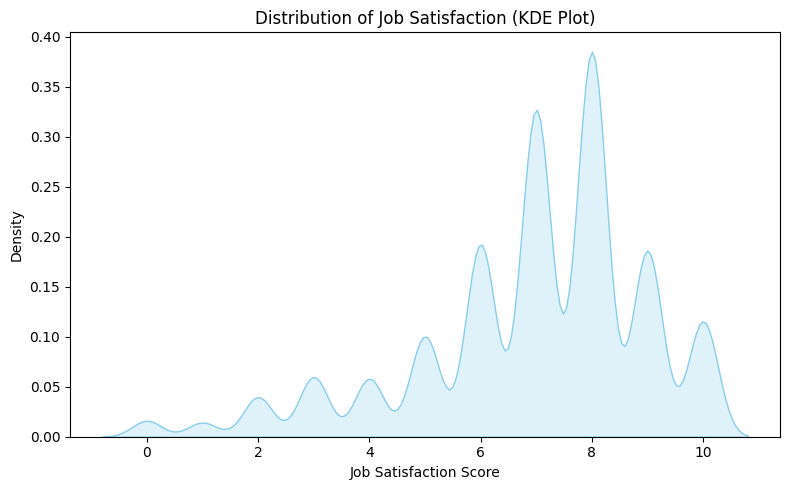

In [7]:
## Write your code here


# Drop missing JobSat values
job_sat_data = df['JobSat'].dropna()

# If JobSat is numeric (e.g., from 0 to 10), use KDE plot
if pd.api.types.is_numeric_dtype(job_sat_data):
    plt.figure(figsize=(8, 5))
    sns.kdeplot(job_sat_data, fill=True, color='skyblue')
    plt.title('Distribution of Job Satisfaction (KDE Plot)')
    plt.xlabel('Job Satisfaction Score')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()
else:
    # If JobSat is categorical (e.g., "Very satisfied", etc.), use pie chart
    job_sat_counts = job_sat_data.value_counts()
    plt.figure(figsize=(8, 8))
    plt.pie(job_sat_counts, labels=job_sat_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    plt.title('Job Satisfaction Distribution (Pie Chart)')
    plt.tight_layout()
    plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


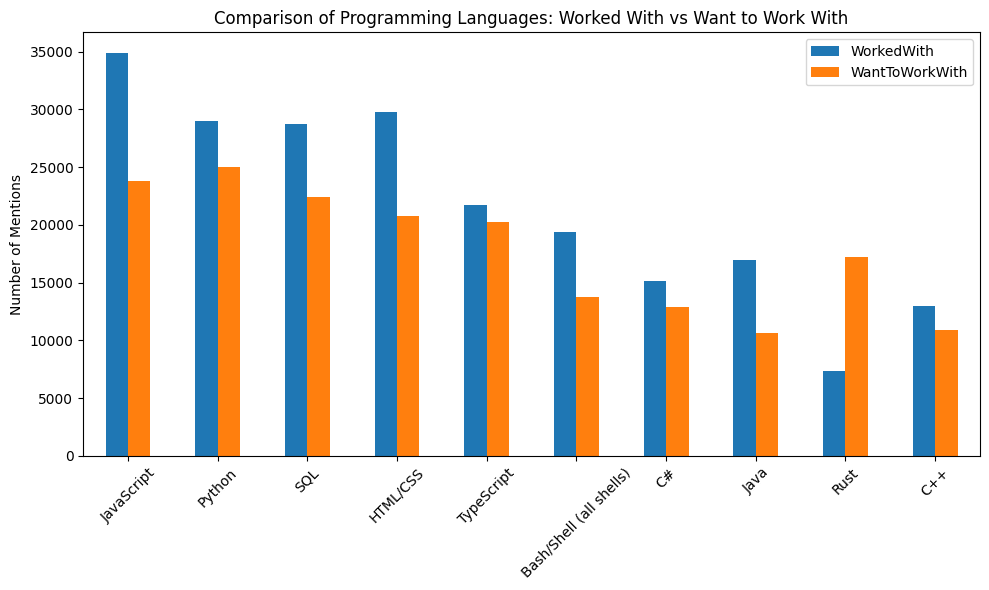

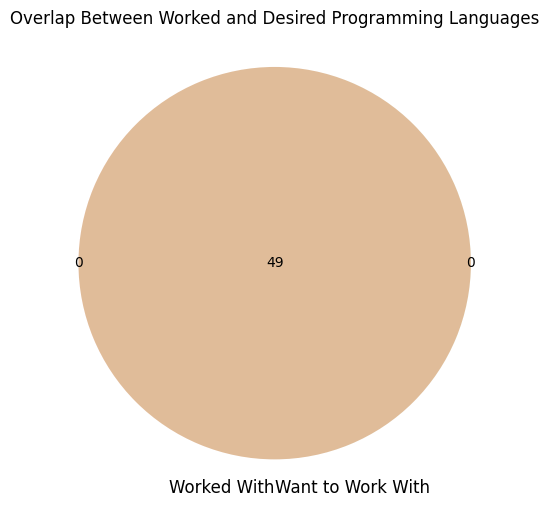

In [11]:
## Write your code here

!pip install matplotlib-venn
from matplotlib_venn import venn2

# Drop rows with missing language data
df_lang = df[['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']].dropna()

# Split semicolon-separated strings into lists
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
df_lang['LanguageWantToWorkWith'] = df_lang['LanguageWantToWorkWith'].str.split(';')

# Explode the lists into rows
worked_langs = df_lang.explode('LanguageHaveWorkedWith')['LanguageHaveWorkedWith'].str.strip()
want_langs = df_lang.explode('LanguageWantToWorkWith')['LanguageWantToWorkWith'].str.strip()

# Get frequency counts
worked_counts = worked_langs.value_counts()
want_counts = want_langs.value_counts()

# For bar chart: create a DataFrame combining both counts
lang_compare = pd.DataFrame({
    'WorkedWith': worked_counts,
    'WantToWorkWith': want_counts
}).fillna(0)

# Select top 10 most common languages from either column
top_langs = lang_compare.sum(axis=1).sort_values(ascending=False).head(10)
lang_compare_top = lang_compare.loc[top_langs.index]

# Plot grouped bar chart
lang_compare_top.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Programming Languages: Worked With vs Want to Work With')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Venn diagram (optional)
set_worked = set(worked_langs.dropna().unique())
set_wanted = set(want_langs.dropna().unique())

plt.figure(figsize=(6, 6))
venn2([set_worked, set_wanted], set_labels=('Worked With', 'Want to Work With'))
plt.title('Overlap Between Worked and Desired Programming Languages')
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


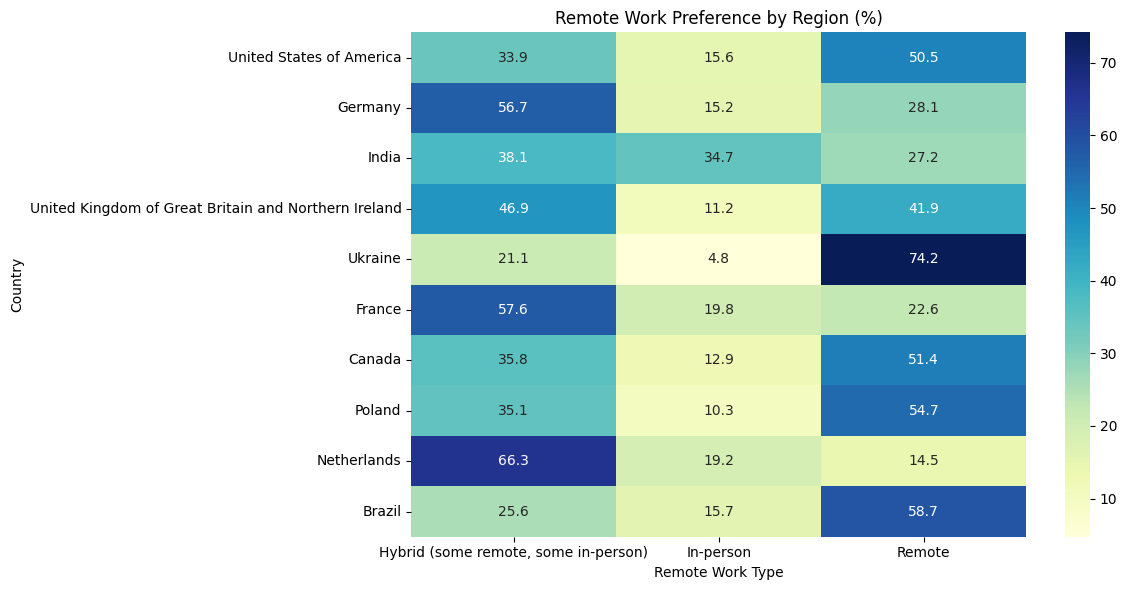

In [12]:
## Write your code here

# Drop missing values in relevant columns
df_remote = df[['Country', 'RemoteWork']].dropna()

# Create cross-tabulation
remote_region_ct = pd.crosstab(df_remote['Country'], df_remote['RemoteWork'])

# Optional: Normalize by row to get percentages
remote_region_pct = remote_region_ct.div(remote_region_ct.sum(axis=1), axis=0) * 100

# Filter top 10 countries with most responses for clarity
top_countries = df['Country'].value_counts().head(10).index
remote_region_pct_top = remote_region_pct.loc[top_countries]

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(remote_region_pct_top, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Remote Work Preference by Region (%)")
plt.xlabel("Remote Work Type")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [13]:
## Write your code here

import pandas as pd
from scipy.stats import pearsonr, spearmanr

# Clean and prepare data
df_corr = df[['JobSat', 'YearsCodePro']].dropna()

# Convert YearsCodePro to numeric
df_corr['YearsCodePro'] = df_corr['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
}).astype(float)

# If JobSat is numeric (e.g., on a 0–10 scale), use directly
# If JobSat is categorical (e.g., "Very satisfied"), map to scores
if not pd.api.types.is_numeric_dtype(df_corr['JobSat']):
    satisfaction_map = {
        'Very dissatisfied': 1,
        'Slightly dissatisfied': 2,
        'Neither satisfied nor dissatisfied': 3,
        'Slightly satisfied': 4,
        'Very satisfied': 5
    }
    df_corr['JobSat'] = df_corr['JobSat'].map(satisfaction_map)

# Drop rows with NaNs after mapping
df_corr = df_corr.dropna()

# Calculate Pearson and Spearman correlation
pearson_corr, _ = pearsonr(df_corr['YearsCodePro'], df_corr['JobSat'])
spearman_corr, _ = spearmanr(df_corr['YearsCodePro'], df_corr['JobSat'])

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: 0.104
Spearman correlation: 0.119


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


/tmp/ipykernel_722/1761197377.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


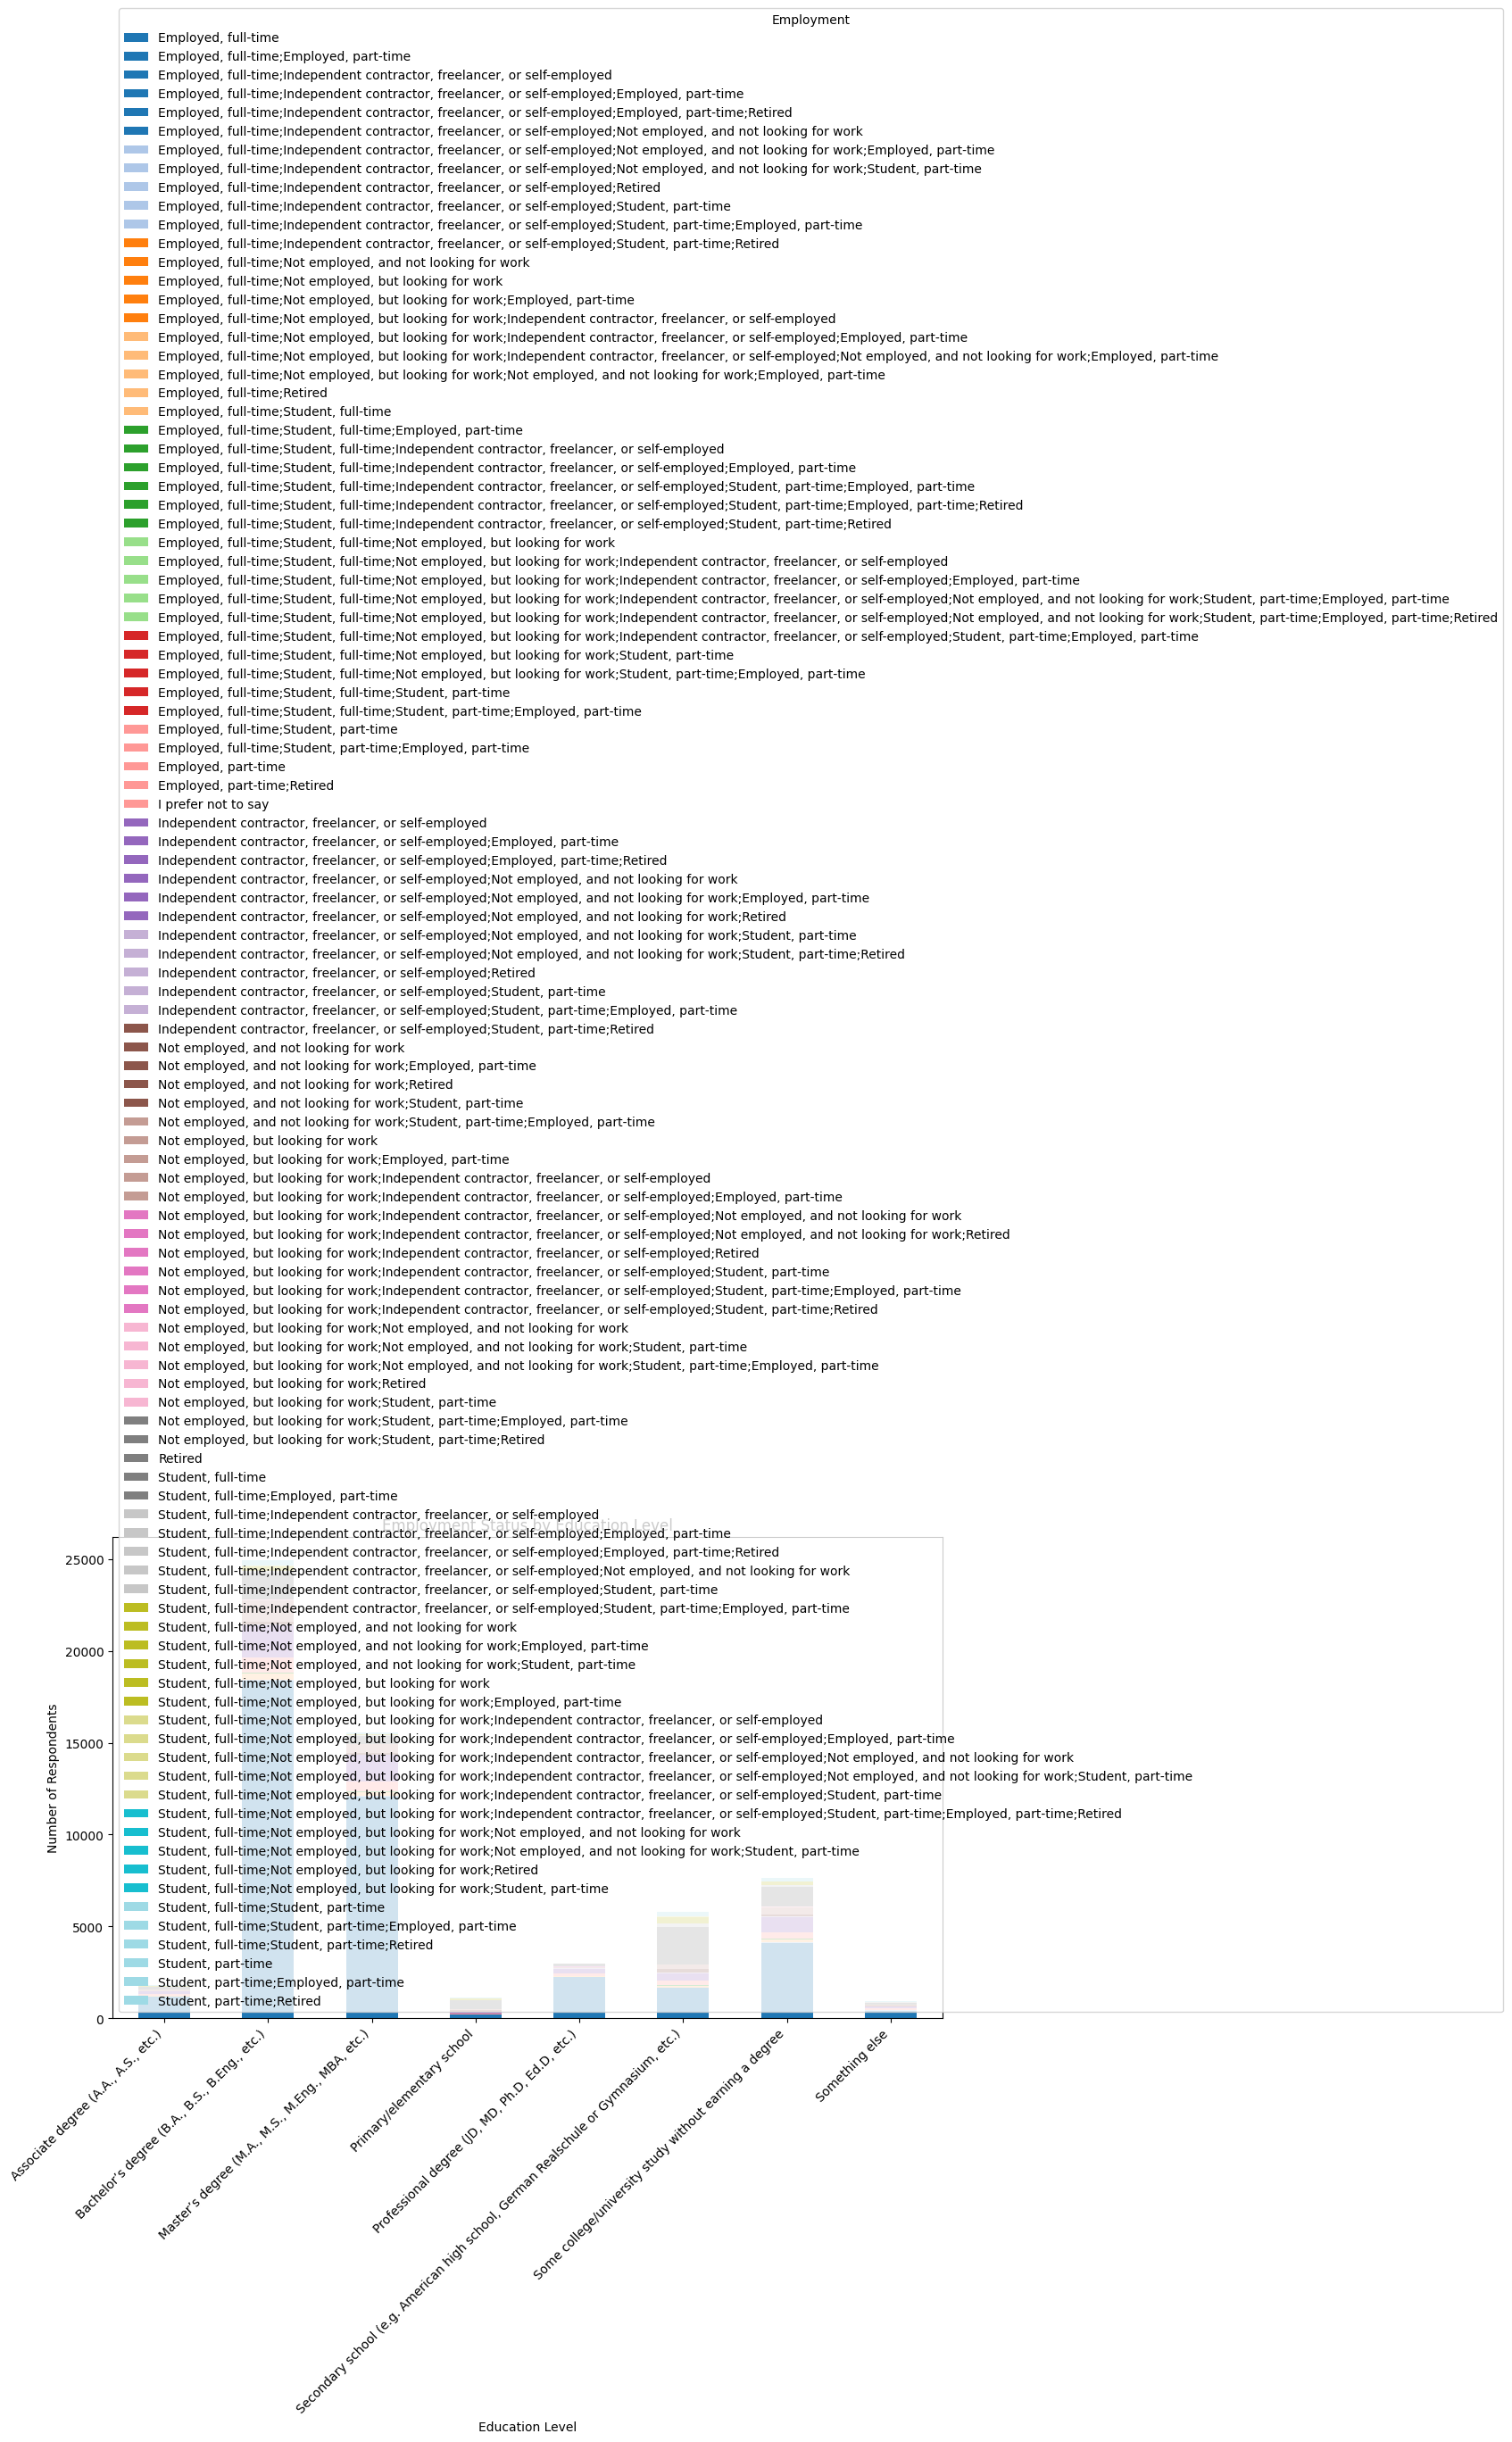

In [14]:
## Write your code here


# Drop missing values in Employment and EdLevel
df_clean = df[['Employment', 'EdLevel']].dropna()

# Create cross-tabulation
edu_emp_ct = pd.crosstab(df_clean['EdLevel'], df_clean['Employment'])

# Plot stacked bar chart
edu_emp_ct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Employment Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [15]:
## Write your code here

df_clean.to_csv("cleaned_survey_data.csv", index=False)

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
